In [47]:
!pip install cmocean
!pip install cmasher



Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/506.5 kB ? eta -:--:--
    --------------------------------------- 10.2/506.5 kB ? eta -:--:--
   -------- ------------------------------- 112.6/506.5 kB 1.3 MB/s eta 0:00:01
   ----------------------------- ---------- 368.6/506.5 kB 2.9 MB/s eta 0:00:01
   ---------------------------------------- 506.5/506.5 kB 2.9 MB/s eta 0:00:00


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


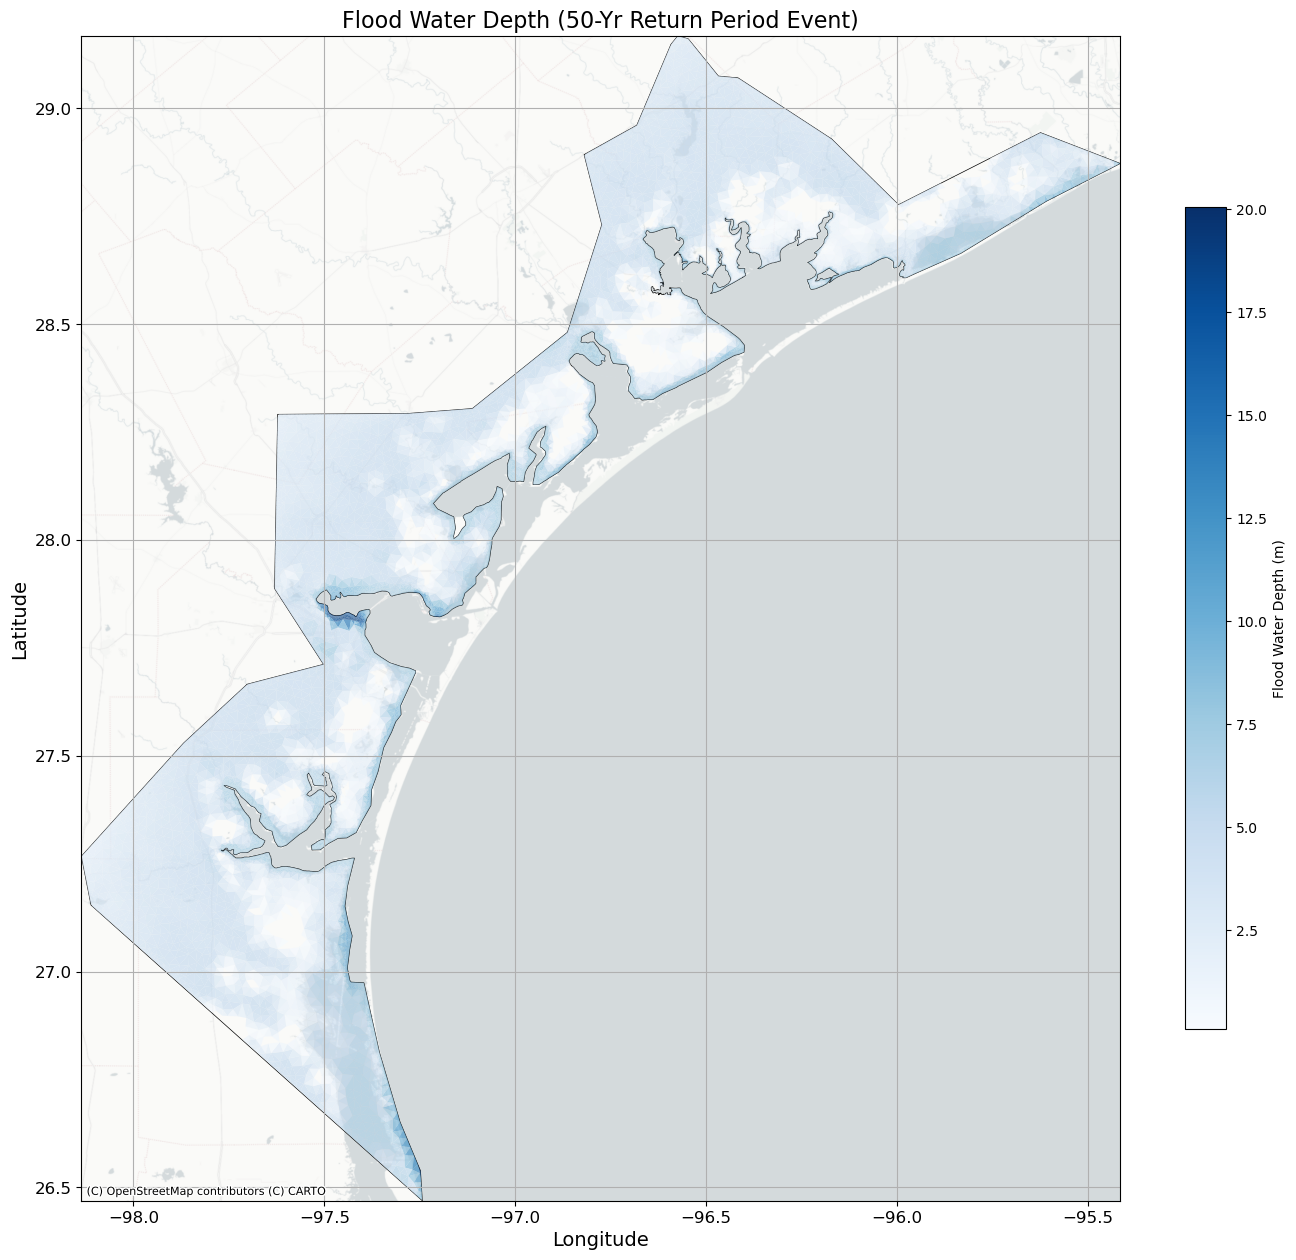

In [7]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx
import mikeio
from shapely.geometry import Polygon

# Step 1: Load DFSU data
dfsu_file = r"D:\Phd Research\Prototype HD Model\Simulation\Without Reef Scenarios\Climate change condition\50-yr return period storm CC.m21fm - Result Files\50-yr_CC_coupled_stat.dfsu"
ds = mikeio.open(dfsu_file)
data = ds.read(items="Statistical maximum : Total water depth")

# Step 2: Load land boundary shapefile
land_shapefile = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"
land_boundary = gpd.read_file(land_shapefile).to_crs("EPSG:32614")

# DFSU Mesh Extraction
geometry = ds.geometry
element_table = geometry.element_table
node_coordinates = geometry.node_coordinates
water_depth = data[0].to_numpy().flatten()  # <-- FIXED!


# Step 4: Create flooded polygons (only where depth > 0.1m)
flooded_polygons = []
depths = []

for elem_idx in range(len(water_depth)):
    if water_depth[elem_idx] > 0.1:  # only meaningful flooding
        nodes = element_table[elem_idx]
        coords = node_coordinates[nodes]
        polygon = Polygon(coords)
        flooded_polygons.append(polygon)
        depths.append(water_depth[elem_idx])

flooded_area_gdf = gpd.GeoDataFrame(
    {'geometry': flooded_polygons, 'depth': depths},
    crs="EPSG:32614"
)

# Step 5: Clip flooded areas with land boundary
flooded_area_clipped = gpd.overlay(flooded_area_gdf, land_boundary, how='intersection', keep_geom_type=False)

# Fix depth values after clipping
flooded_area_clipped['depth'] = flooded_area_clipped['depth'].apply(lambda x: np.mean(x) if isinstance(x, (np.ndarray, list)) else x)

# Step 6: Convert to EPSG:4326 for plotting
land_boundary = land_boundary.to_crs("EPSG:4326")
flooded_area_clipped = flooded_area_clipped.to_crs("EPSG:4326")

# Step 7: Plotting
fig, ax = plt.subplots(figsize=(14,14))

# Plot land boundary
land_boundary.plot(ax=ax, color='none', edgecolor='black', linewidth=0.5)

# Plot flooded areas with continuous color ramp
flooded_area_clipped.plot(
    ax=ax,
    column='depth',
    cmap='Blues',    # Continuous blue color ramp
    alpha=0.7,
    edgecolor='none',
    legend=True,
    legend_kwds={'label': "Flood Water Depth (m)", 'shrink': 0.6, 'orientation': 'vertical'}
)

# Add basemap
ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.CartoDB.PositronNoLabels, zoom=10)

# Set zoom based on land boundary
xmin, ymin, xmax, ymax = land_boundary.total_bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# Clean axis (no lat/lon formatting, just numbers)
ax.set_xlabel("Longitude", fontsize=14)
ax.set_ylabel("Latitude", fontsize=14)
ax.set_title('Flood Water Depth (50-Yr Return Period Event)', fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


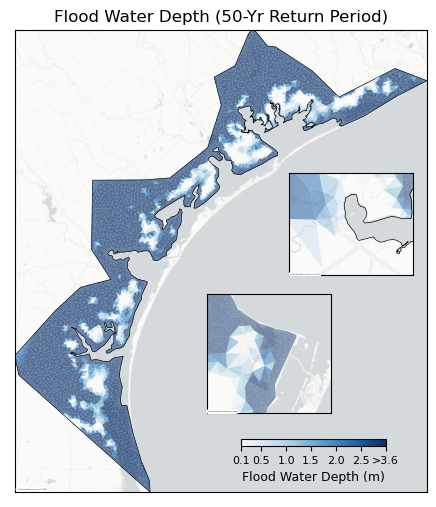

In [54]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx
import mikeio
from shapely.geometry import Polygon
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes



# Step 1: Load DFSU data
dfsu_file = r"D:\Phd Research\Prototype HD Model\Simulation\Without Reef Scenarios\Climate change condition\50-yr return period storm CC.m21fm - Result Files\50-yr_CC_coupled_stat.dfsu"
ds = mikeio.open(dfsu_file)
data = ds.read(items="Statistical maximum : Total water depth")

# Step 2: Load land boundary
land_shapefile = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"
land_boundary = gpd.read_file(land_shapefile).to_crs("EPSG:32614")

# Step 3: DFSU Mesh
geometry = ds.geometry
element_table = geometry.element_table
node_coordinates = geometry.node_coordinates
water_depth = data[0].to_numpy().flatten()

# Step 4: Create flooded polygons (only where depth > 0.1m)
flooded_polygons = []
depths = []

for elem_idx in range(len(water_depth)):
    if water_depth[elem_idx] > 0.1:
        nodes = element_table[elem_idx]
        coords = node_coordinates[nodes]
        polygon = Polygon(coords)
        flooded_polygons.append(polygon)
        depths.append(water_depth[elem_idx])

flooded_area_gdf = gpd.GeoDataFrame(
    {'geometry': flooded_polygons, 'depth': depths},
    crs="EPSG:32614"
)

# Step 5: Clip flooded areas with land boundary
flooded_area_clipped = gpd.overlay(flooded_area_gdf, land_boundary, how='intersection', keep_geom_type=False)

# Fix depth after clipping
flooded_area_clipped['depth'] = flooded_area_clipped['depth'].apply(lambda x: np.mean(x) if isinstance(x, (np.ndarray, list)) else x)

# Step 6: Reproject to EPSG:4326
land_boundary = land_boundary.to_crs("EPSG:4326")
flooded_area_clipped = flooded_area_clipped.to_crs("EPSG:4326")

# Step 7: Set vmin and vmax
vmin_fixed = 0.1
vmax_fixed = 3.0

# Step 8: Plotting
fig, ax = plt.subplots(figsize=(6,6))

# Plot land boundary
land_boundary.plot(ax=ax, color='none', edgecolor='black', linewidth=0.5)

# Plot flooded areas
flooded_area_clipped.plot(
    ax=ax,
    column='depth',
    cmap='Blues',
    alpha=0.7,
    edgecolor='none',  # ✅ No mesh lines
    legend=False,
    vmin=vmin_fixed,
    vmax=vmax_fixed
)

# Add basemap to main figure
ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.CartoDB.PositronNoLabels, zoom=10, attribution_size=0)

# Zoom to land boundary
xmin, ymin, xmax, ymax = land_boundary.total_bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# Remove ticks and labels
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title('Flood Water Depth (50-Yr Return Period)', fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=12)

# Step 9: Add horizontal colorbar inside map
axins_cbar = inset_axes(
    ax,
    width="50%", height="5%",
    loc='lower right',
    bbox_to_anchor=(0.2, 0.1, 0.7, 0.3),
    bbox_transform=ax.transAxes,
    borderpad=0
)

norm = mpl.colors.Normalize(vmin=0.1, vmax=3.0)
sm = mpl.cm.ScalarMappable(cmap='Blues', norm=norm)
sm._A = []

cbar = plt.colorbar(sm, cax=axins_cbar, orientation="horizontal")
cbar.set_label('Flood Water Depth (m)', fontsize=9)
cbar.set_ticks([0.1, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0])
cbar.ax.set_xticklabels(['0.1', '0.5', '1.0', '1.5', '2.0', '2.5', '>3.6'])
cbar.ax.tick_params(labelsize=8)

# Step 10: First inset map (Port Lavaca region)
axins_map1 = inset_axes(
    ax,
    width="60%", height="60%",
    bbox_to_anchor=(0.5, 0.4, 0.5, 0.5),  # higher
    bbox_transform=ax.transAxes,
    loc='lower right',
    borderpad=1
)

flooded_area_clipped.plot(
    ax=axins_map1,
    column='depth',
    cmap='Blues',
    alpha=0.5,
    edgecolor='none',
    vmin=0.1,
    vmax=3.0,
    legend=False
)
land_boundary.plot(ax=axins_map1, color='none', edgecolor='black', linewidth=0.5)

ctx.add_basemap(axins_map1, crs="EPSG:4326", source=ctx.providers.CartoDB.PositronNoLabels, zoom=12, attribution_size=0)

# Set bounding box for first inset
axins_map1.set_xlim(-96.664495, -96.618919)
axins_map1.set_ylim(28.560627, 28.593942)
axins_map1.set_xticks([])
axins_map1.set_yticks([])

# Step 11: Second inset map (Corpus Christi region)
axins_map2 = inset_axes(
    ax,
    width="60%", height="60%",
    bbox_to_anchor=(0.3, 0.12, 0.5, 0.5),  # lower
    bbox_transform=ax.transAxes,
    loc='lower right',
    borderpad=1
)

flooded_area_clipped.plot(
    ax=axins_map2,
    column='depth',
    cmap='Blues',
    alpha=0.5,
    edgecolor='none',
    vmin=0.1,
    vmax=3.0,
    legend=False
)
land_boundary.plot(ax=axins_map2, color='none', edgecolor='none', linewidth=0)

ctx.add_basemap(axins_map2, crs="EPSG:4326", source=ctx.providers.CartoDB.PositronNoLabels, zoom=12, attribution_size=0)

# Set bounding box for second inset
axins_map2.set_xlim(-97.426071, -97.197418)
axins_map2.set_ylim(27.569765, 27.763153)
axins_map2.set_xticks([])
axins_map2.set_yticks([])

# Final plot
plt.show()
